In [2]:
# CleanIscData.py

input_file = "IscAngleData.txt"
output_file = "Cleaned_IscAngleData.csv"

with open(input_file, "r", encoding="utf-8-sig") as infile, open(output_file, "w", encoding="utf-8") as outfile:
    for line in infile:
        parts = [x.strip() for x in line.strip().split(",") if x.strip()]
        if len(parts) >= 2:
            outfile.write(f"{parts[0]},{parts[1]}\n")


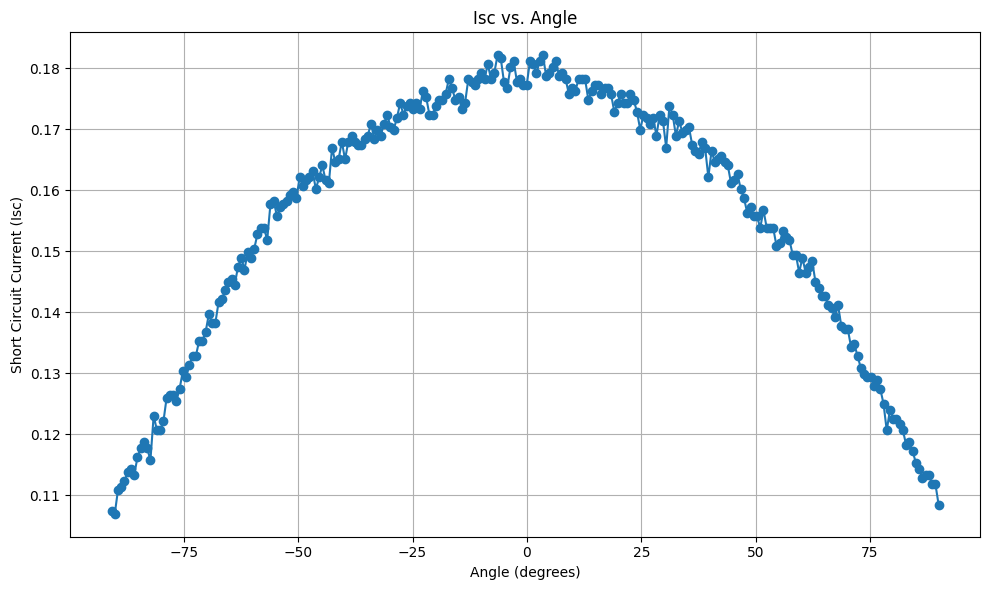

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV data
data = np.loadtxt("Cleaned_IscAngleData.csv", delimiter=",")

# Split into two arrays
current = data[:, 0]  # First column
angle = data[:, 1]    # Second column

# Plot
plt.figure(figsize=(10, 6))
plt.plot(angle, current, marker='o', linestyle='-')
plt.xlabel("Angle (degrees)")
plt.ylabel("Short Circuit Current (Isc)")
plt.title("Isc vs. Angle")
plt.grid(True)
plt.tight_layout()
plt.show()


Fitted peak Isc: 0.179337 A
Fitted peak angle: -0.44°


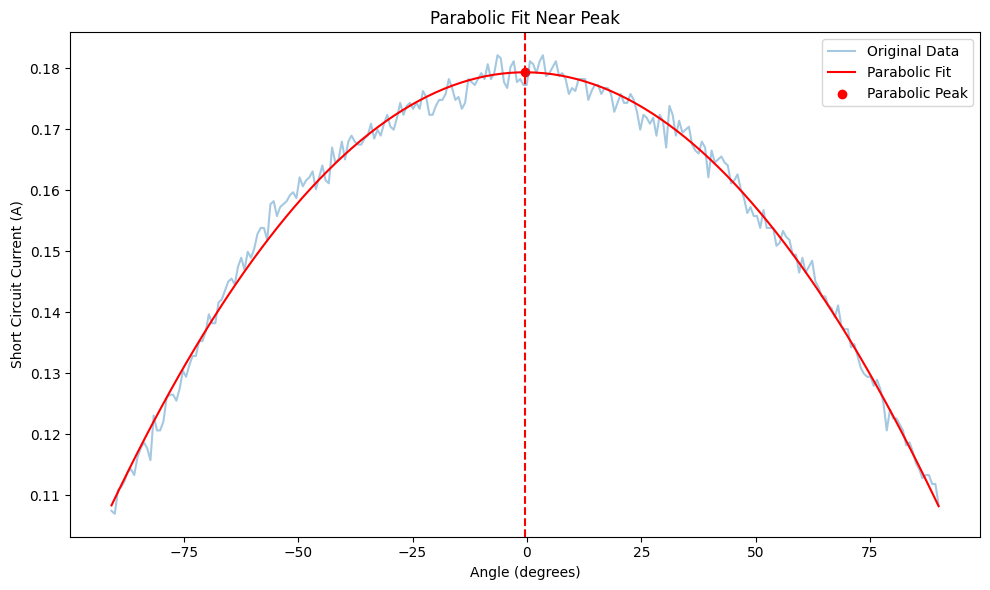

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt("Cleaned_IscAngleData.csv", delimiter=",")
isc = data[:, 0]
angle = data[:, 1]

# Step 1: Find rough peak location from raw data
rough_peak_index = np.argmax(isc)

# Step 2: Fit a parabola to a small region around the peak
window_size = 300  # must be at least 3, odd is best
half_window = window_size // 2
start = max(0, rough_peak_index - half_window)
end = min(len(angle), rough_peak_index + half_window + 1)

angle_window = angle[start:end]
isc_window = isc[start:end]

# Step 3: Fit a quadratic (parabola): Isc = a*angle^2 + b*angle + c
coeffs = np.polyfit(angle_window, isc_window, 2)
a, b, c = coeffs

# Vertex (peak) of parabola: angle = -b / (2a)
peak_angle = -b / (2 * a)
peak_isc = a * peak_angle**2 + b * peak_angle + c

print(f"Fitted peak Isc: {peak_isc:.6f} A")
print(f"Fitted peak angle: {peak_angle:.2f}°")

# Optional: Plot
fit_angles = np.linspace(min(angle_window), max(angle_window), 200)
fit_isc = a * fit_angles**2 + b * fit_angles + c

plt.figure(figsize=(10, 6))
plt.plot(angle, isc, label="Original Data", alpha=0.4)
plt.plot(fit_angles, fit_isc, label="Parabolic Fit", color='red')
plt.scatter([peak_angle], [peak_isc], color='red', label='Parabolic Peak')
plt.axvline(peak_angle, color='red', linestyle='--')
plt.xlabel("Angle (degrees)")
plt.ylabel("Short Circuit Current (A)")
plt.title("Parabolic Fit Near Peak")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()
